# 1. K-Nearest Neighbors (KNN) Regression

## Introduction

K-Nearest Neighbors (KNN) Regression is a supervised machine learning algorithm used to predict continuous numerical values. It works by finding the K nearest data points to a new input using a distance metric (such as Euclidean or Manhattan distance) and predicts the output based on the average (or weighted average) of those neighbors.

Unlike many algorithms, KNN does not build a mathematical model during training. Instead, it stores the training data and performs prediction only when a new data point is given. Because KNN relies on distances, feature scaling (Standardization or Normalization) is important for better performance.

## Applications

* House price prediction
* Salary prediction
* Sales forecasting
* Weather prediction
* Medical data analysis


## 1. IMPORT LIBRARIES


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [5]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

## 2.Read Dataset

In [6]:
dataset = pd.read_csv(r"C:\Users\Lenovo\Downloads\student_placement_salary_elite_v2.csv")

In [24]:
dataset.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


In [17]:
dataset.info

<bound method DataFrame.info of      student_id  cgpa      branch  college_tier  python_skill  dsa_skill  \
0            S0  6.87       Civil             1             1          1   
1            S1  6.52       Civil             2             1          0   
2            S2  5.33          IT             1             1          1   
3            S3  6.04       Civil             3             1          0   
4            S4  6.78  Mechanical             2             0          1   
...         ...   ...         ...           ...           ...        ...   
8995      S8995  6.51          IT             2             1          0   
8996      S8996  7.74          IT             3             1          1   
8997      S8997  7.14         CSE             3             1          0   
8998      S8998  5.21          IT             1             1          0   
8999      S8999  6.05       Civil             2             1          1   

      ml_skill  web_dev_skill  coding_score  communicat

In [18]:
dataset.dtypes

student_id              object
cgpa                   float64
branch                  object
college_tier             int64
python_skill             int64
dsa_skill                int64
ml_skill                 int64
web_dev_skill            int64
coding_score           float64
communication_score    float64
aptitude_score         float64
internships              int64
projects                 int64
backlogs                 int64
resume_score           float64
skill_score              int64
placed                   int64
company_type            object
job_role                object
salary_lpa             float64
dtype: object

In [20]:
dataset.columns

Index(['student_id', 'cgpa', 'branch', 'college_tier', 'python_skill',
       'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score',
       'communication_score', 'aptitude_score', 'internships', 'projects',
       'backlogs', 'resume_score', 'skill_score', 'placed', 'company_type',
       'job_role', 'salary_lpa'],
      dtype='object')

## Remove Student id

In [28]:
dataset = dataset.drop("student_id", axis=1) # are only IDs.They have no effect on salary prediction.

## Convert the text columns to numbers

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset["branch"] = le.fit_transform(dataset["branch"])

dataset["company_type"] = le.fit_transform(dataset["company_type"])

dataset["job_role"] = le.fit_transform(dataset["job_role"])

In [30]:
print(dataset.head())  # let see here Everything should now be numeric.

   cgpa  branch  college_tier  python_skill  dsa_skill  ml_skill  \
0  6.87       1             1             1          1         0   
1  6.52       1             2             1          0         0   
2  5.33       4             1             1          1         1   
3  6.04       1             3             1          0         1   
4  6.78       5             2             0          1         0   

   web_dev_skill  coding_score  communication_score  aptitude_score  \
0              0          15.6                  4.3            92.0   
1              1          13.9                  5.8            62.0   
2              0           9.8                  8.1            66.4   
3              0          39.5                  9.6            83.6   
4              1           7.5                  9.9            86.3   

   internships  projects  backlogs  resume_score  skill_score  placed  \
0            1         3         0          62.6            2       1   
1            1    

## Seprate the X and Y

In [32]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

## 3. Spilt Dataset

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## 4. Feaature Scaling 

In [34]:
sc_X= StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train =  sc_y.fit_transform(y_train.reshape(-1,1)).ravel()
                             

## 5.Create model 

In [45]:
# Model 1:
model = KNeighborsRegressor(
    n_neighbors =5, weights = 'distance', algorithm = 'auto', p=2)
model.fit(X_train,y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [70]:
# Model 2:  for euclidean distance
model = KNeighborsRegressor(
    n_neighbors =5, weights = 'distance', algorithm = 'auto',metric ='minkowski', p=2)
model.fit(X_train,y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [58]:
# Model 3 : Euclidean Metric
model = KNeighborsRegressor(
    n_neighbors =8, weights = 'distance', algorithm = 'auto',metric ='euclidean')
model.fit(X_train,y_train)

,n_neighbors,8
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [59]:
# Model 3 : for manhatten distance
model = KNeighborsRegressor(
    n_neighbors =76, weights = 'distance', algorithm = 'auto',metric ='minkowski', p=1)
model.fit(X_train,y_train)

,n_neighbors,76
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
# Model  : Manhatten Metric
model = KNeighborsRegressor(
    n_neighbors =150, weights = 'distance', algorithm = 'auto',metric ='manhattan')
model.fit(X_train,y_train)

,n_neighbors,150
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [62]:
#
model = KNeighborsRegressor(
    n_neighbors =250, weights = 'distance', algorithm = 'brute',metric ='minkowski', p=1)
model.fit(X_train,y_train)

,n_neighbors,250
,weights,'distance'
,algorithm,'brute'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [67]:
model = KNeighborsRegressor(
    n_neighbors =7, weights = 'uniform', algorithm = 'kd_tree',metric ='euclidean', p=2)

model.fit(X_train,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [68]:
model = KNeighborsRegressor(
    n_neighbors =3, weights = 'distance', algorithm = 'ball_tree',metric ='manhattan')

model.fit(X_train,y_train)

,n_neighbors,3
,weights,'distance'
,algorithm,'ball_tree'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [69]:
# Model   : Chebyshev distance
model = KNeighborsRegressor(
    n_neighbors =9, weights = 'uniform', algorithm = 'brute',metric ='chebyshev')

model.fit(X_train,y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'brute'
,leaf_size,30
,p,2
,metric,'chebyshev'
,metric_params,None
,n_jobs,None


In [66]:
# Model : Cosine Distance
model = KNeighborsRegressor(
    n_neighbors =5, weights = 'distance', algorithm = 'brute',metric ='cosine')
model.fit(X_train,y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'brute'
,leaf_size,30
,p,2
,metric,'cosine'
,metric_params,None
,n_jobs,None


In [65]:
# Model  :  Cosine Metric
model = KNeighborsRegressor(
    n_neighbors =5, weights = 'distance', algorithm = 'brute',metric ='cosine', p=1)

model.fit(X_train,y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'brute'
,leaf_size,30
,p,1
,metric,'cosine'
,metric_params,None
,n_jobs,None


## Prediction 

In [72]:
pred=sc_y.inverse_transform(model.predict(X_test).reshape(-1,1))

y_test_original=y_test.reshape(-1,1)

## Metrics

In [74]:
print("MAE :",mean_absolute_error(y_test_original,pred))
print("MSE :",mean_squared_error(y_test_original,pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test_original,pred)))
print("R2 :",r2_score(y_test_original,pred))


MAE : 6.294584677469221
MSE : 82.21996642938667
RMSE : 9.067522618079686
R2 : 0.8970458489936564


## Predict Data Value

In [77]:
print(X.shape)

print(X_train.shape)

print(sc_X.n_features_in_)

(9000, 18)
(7200, 18)
18


In [78]:
prediction = model.predict(X_test) # predict test data

print(prediction)

[ 0.77356459  0.54203225  0.76025889 ...  0.68947107 -0.43528987
 -0.47036096]


In [79]:
prediction = model.predict(X_test[:1])  # predict first test sample

print(prediction)

[0.77356459]


In [80]:
prediction = model.predict(X[99:100])   # Predict any row from dataset

print(prediction)

[1.05119989]


## Visulazation 

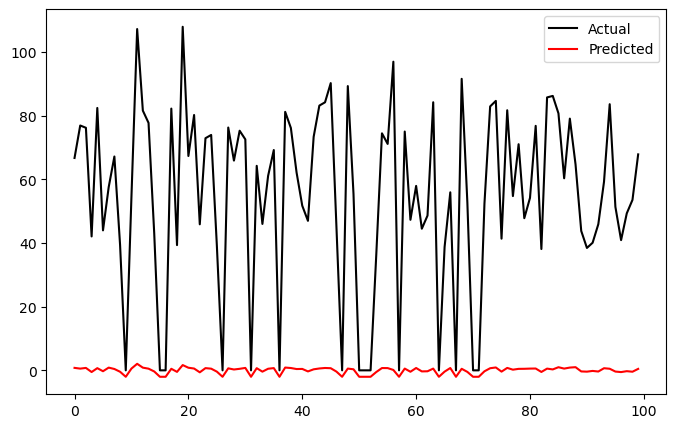

In [91]:
# Method 1 : Compare Actual  vs  Predicted values
pred = model.predict(X_test)

plt.figure(figsize=(8,5))

plt.plot(y_test[:100], label='Actual', color='black')

plt.plot(pred[:100], label='Predicted', color = 'red')

plt.legend()

plt.show()

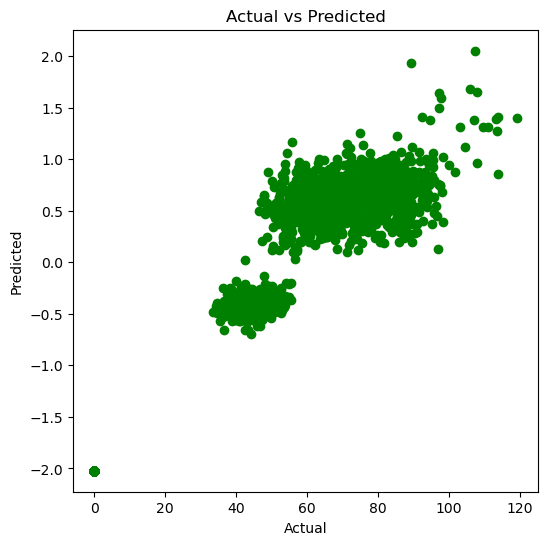

In [86]:
# Method 2 : Scatter plot

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, color= 'green')

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

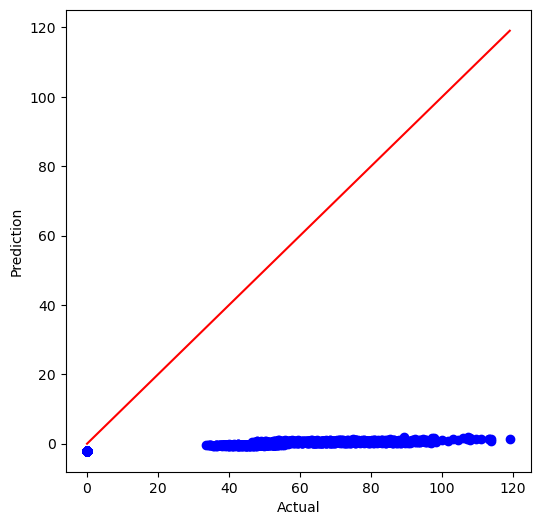

In [89]:
# Method 3 : Regression Line

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, color='blue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")

plt.ylabel("Prediction")

plt.show()